In [1]:
import os
import jax
import zodiax as zdx
from zodiax.optimisation import sgd, adam
from jax import numpy as np, random as jr, tree as jtu
from scipy.ndimage import binary_dilation
import dLux.utils as dlu

jax.config.update("jax_enable_x64", True)

import amigo
import dorito
import astropy

# visualisation
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots
import cmasher as cmr

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])

plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)

2025-04-30 21:47:54.739287: W external/xla/xla/service/gpu/nvptx_compiler.cc:893] The NVIDIA driver's CUDA version is 12.4 which is older than the PTX compiler version 12.6.85. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


In [2]:
from socket import gethostname

if gethostname() == "glinton":
    cache = "/media/morgana1/snert/max/data/amigo_files/"
    data_path = "/media/morgana1/snert/max/data/JWST/WR137/calslope/"
    uncal_path = "/media/morgana1/snert/max/data/JWST/WR137/uncal/"
else:
    cache = "/Volumes/morgana1/snert/max/data/amigo_files/"
    data_path = "/Volumes/morgana1/snert/max/data/JWST/WR137/calslope/"
    uncal_path = "/Volumes/morgana1/snert/max/data/JWST/WR137/uncal/"
fisher_cache = os.path.join(cache, "fishers/")
model_cache = os.path.join(cache, "models/")
teff_cache = os.path.join(cache, "Teffs/")
init_state_cache = os.path.join(cache, "init_states/WR137/")
output_path = os.path.join(cache, "outputs/WR137/")

state = np.load(os.path.join(model_cache, "static_model.npy"), allow_pickle=True).item()

EXP_TYPE = "NIS_AMI"
FILTERS = [
    "F480M",
    # "F430M",
    # "F380M",
    # "F277W",
]

# Bind file path, type and exposure type
file_fn = lambda data_path, filters=FILTERS, **kwargs: amigo.files.get_files(
    # "/Users/mcha5804/JWST/ERS1373/calgrps/",
    data_path,
    "calslope",
    EXP_TYPE=EXP_TYPE,
    FILTER=filters,
    **kwargs,
)

# Loading in data

In [3]:
files = sorted(
    file_fn(data_path), key=lambda hdu: hdu[0].header.get("EXPMID", float("inf"))
)
# nsci = 1; ncal = 4
rolls = {}
sci_files = []
cal_files = []

for file in files:

    filename = file[0].header["FILENAME"].replace("_nis_calslope.fits", "")
    rolls[filename] = dorito.plotting.calc_parang(file)

    # manual bad pixel correction
    file["BADPIX"].data[58, 67] = 1
    file["BADPIX"].data[71, 22] = 1
    file["BADPIX"].data[65, 41] = 1
    file["BADPIX"].data[35, 70] = 1
    file["BADPIX"].data[70, 55] = 1
    file["BADPIX"].data[5, 5] = 1
    file["BADPIX"].data[-4, 37] = 1
    file["BADPIX"].data[51, 27] = 1
    file["BADPIX"].data[28, 18] = 1
    file["BADPIX"].data[32, 10] = 1

    file["BADPIX"].data[:, :3] = 1
    file["BADPIX"].data[:, -3:] = 1
    file["BADPIX"].data[:3, :] = 1
    file["BADPIX"].data[-3:, :] = 1
    # file["BADPIX"].data[36:66, :25] = 1  # BACKGROUND STAR?
    # file["BADPIX"].data[40, 45] = 1  # MIDDLE PIXELS

    badpix = np.array(file["BADPIX"].data, dtype=bool)
    im = np.array(file["SLOPE"].data.sum(0))
    im = np.where(badpix, np.nan, im)
    mask = binary_dilation(im == np.nanmax(im), iterations=2)
    file["BADPIX"].data += mask.astype(int)

    if not bool(file[0].header["IS_PSF"]):
        sci_files.append(file)
    elif bool(file[0].header["IS_PSF"]):
        file[0].header["TARGPROP"] = "HD 228337"
        cal_files.append(file)
    else:
        print(f"Unkown target: {file[0].header['TARGPROP']}")

In [4]:
import zodiax as zdx
import equinox as eqx
import dLux as dl
from jax import vmap
from amigo.misc import interp
from amigo.vis_models import wf_fft_coords


def vis_to_im(amps, phases, shape):
    # Conjugate the amplitudes and phases
    amp = np.concatenate([amps, np.array([0.0]), amps[::-1]], axis=0)
    phase = np.concatenate([phases, np.array([0.0]), -phases[::-1]], axis=0)
    return amp.reshape(shape), phase.reshape(shape)


def inject_vis(wfs, log_amps, phases, otf_coords):
    # Get the amplitudes and phases
    log_amps, phase = vis_to_im(log_amps, phases, otf_coords.shape[1:])

    # Interpolate the visibility maps to uv coordinates
    uv_coords = wf_fft_coords(wfs, pad=2)
    interp_fn = lambda im, uv: interp(im, otf_coords, uv, method="linear", fill=0.0)
    log_amps = vmap(lambda uv: interp_fn(log_amps, uv))(uv_coords)
    phases = vmap(lambda uv: interp_fn(phase, uv))(uv_coords)

    # Fourier Functions (use 2x pad)
    n = uv_coords.shape[-1] // 4
    crop_fn = lambda x: x[n:-n, n:-n]
    pad_fn = lambda x: np.pad(x, n, mode="constant")
    to_uv = vmap(lambda x: np.fft.fftshift(np.fft.fft2(pad_fn(x))))
    from_uv = vmap(lambda x: crop_fn(np.fft.ifft2(np.fft.ifftshift(x))))

    # Apply the visibility maps
    splodges = to_uv(wfs.psf) * np.exp(log_amps + 1j * phases)
    return np.abs(from_uv(splodges)).sum(0)


def project(latent_vis, V):
    vis_vec = np.dot(latent_vis, V)
    log_amp, phase = np.array_split(vis_vec, 2, axis=0)
    return log_amp, phase


def model_vis_psf(optics, latent_vis, filter, aberrations, defocus, n_knots=51):
    # Update the optics to the correct aberrations and defocus
    optics = optics.set(
        ["pupil_mask.abb_coeffs", "defocus"],
        [aberrations, defocus],
    )

    # Model the wavefront
    wavels, weights = optics.filters[filter]
    wfs = eqx.filter_jit(optics.propagate)(wavels, weights=weights, return_wf=True)

    # Inject the visibility maps
    otf_coords = dlu.pixel_coords(n_knots, 2 * optics.diameter)
    log_amps, phases = np.array_split(latent_vis, 2, axis=0)
    return inject_vis(wfs, log_amps, phases, otf_coords)


def decompose(J, values):
    """Compute Hessian and its eigendecomposition safely on GPU."""
    # Form diagonal covariance matrix
    cov = np.eye(values.size) * values[..., None]

    # Hessian estimate
    hess = J @ (cov @ J.T)

    # Force symmetry
    hess = 0.5 * (hess + hess.T)

    # Remove NaNs/Infs
    hess = np.nan_to_num(hess, nan=0.0, posinf=0.0, neginf=0.0)

    try:
        eigvals, eigvecs = np.linalg.eigh(hess)
    except Exception as e:
        print("WARNING: eigh failed, falling back to eig. Error:", e)
        eigvals, eigvecs = np.linalg.eig(hess)
        eigvecs = eigvecs.T  # match expected output shape

    eigvecs = np.real(eigvecs)
    eigvals = np.real(eigvals)
    eigvals /= eigvals[0]  # normalize

    eigvals = eigvals[::-1]
    eigvecs = eigvecs[:, ::-1]

    return hess, eigvals, eigvecs


# def decompose(J, values):
#     """
#     I replaced eig with eigh
#     """
#     # Get the covariance matrix
#     cov = np.eye(values.size) * values[..., None]

#     # Get the hessian
#     hess = J @ (cov @ J.T)

#     # Get the eigenvalues and eigenvectors
#     hess = 0.5 * (hess + hess.T)
#     assert np.all(np.isfinite(hess)), "Hessian has NaNs or Infs"
#     eigvals, eigvecs = np.linalg.eigh(hess)
#     eigvals = eigvals[::-1]
#     eigvecs = eigvecs[:, ::-1]

#     eigvecs, eigvals = np.real(eigvecs).T, np.real(eigvals)

#     #
#     eigvals /= eigvals[0]
#     return hess, eigvals, eigvecs

In [5]:
from amigo.misc import tqdm
from amigo.stats import batched_jacobian
import dLux.utils as dlu
from amigo.optical_models import AMIOptics


optics = AMIOptics()

n_terms = 800
eig_mats = {}
outputs = {}
for filt in tqdm(FILTERS):
    n_knots = 51
    n_pts = (n_knots**2) - 1  # dont control the DC term
    vis_vec = np.zeros(n_pts)
    abb = state["aberrations"][f"04481_{filt}"]
    defoc = state["defocus"][filt]

    output_fn = lambda x: dlu.downsample(x, 3, mean=False).flatten()
    vis_fn = lambda vis_vec: output_fn(
        model_vis_psf(optics, vis_vec, filt, abb, defoc, n_knots)
    )

    #
    psf = vis_fn(vis_vec)
    J = batched_jacobian(vis_vec, lambda X: vis_fn(X), n_batch=40)
    # H, eig_vals, eig_vecs = decompose(J, psf)
    J_amp, J_phase = np.split(J, 2, axis=0)
    H_amp, eig_vals_amp, eig_vecs_amp = decompose(J_amp, psf)
    H_phase, eig_vals_phase, eig_vecs_phase = decompose(J_phase, psf)

    #
    outputs[filt] = {
        "amplitudes": {
            "J": J_amp,
            "H": H_amp,
            "eig_vals": eig_vals_amp,
            "eig_vecs": eig_vecs_amp,
        },
        "phases": {
            "J": J_phase,
            "H": H_phase,
            "eig_vals": eig_vals_phase,
            "eig_vecs": eig_vecs_phase,
        },
    }

  0%|          | 0/1 [00:00<?, ?it/s]

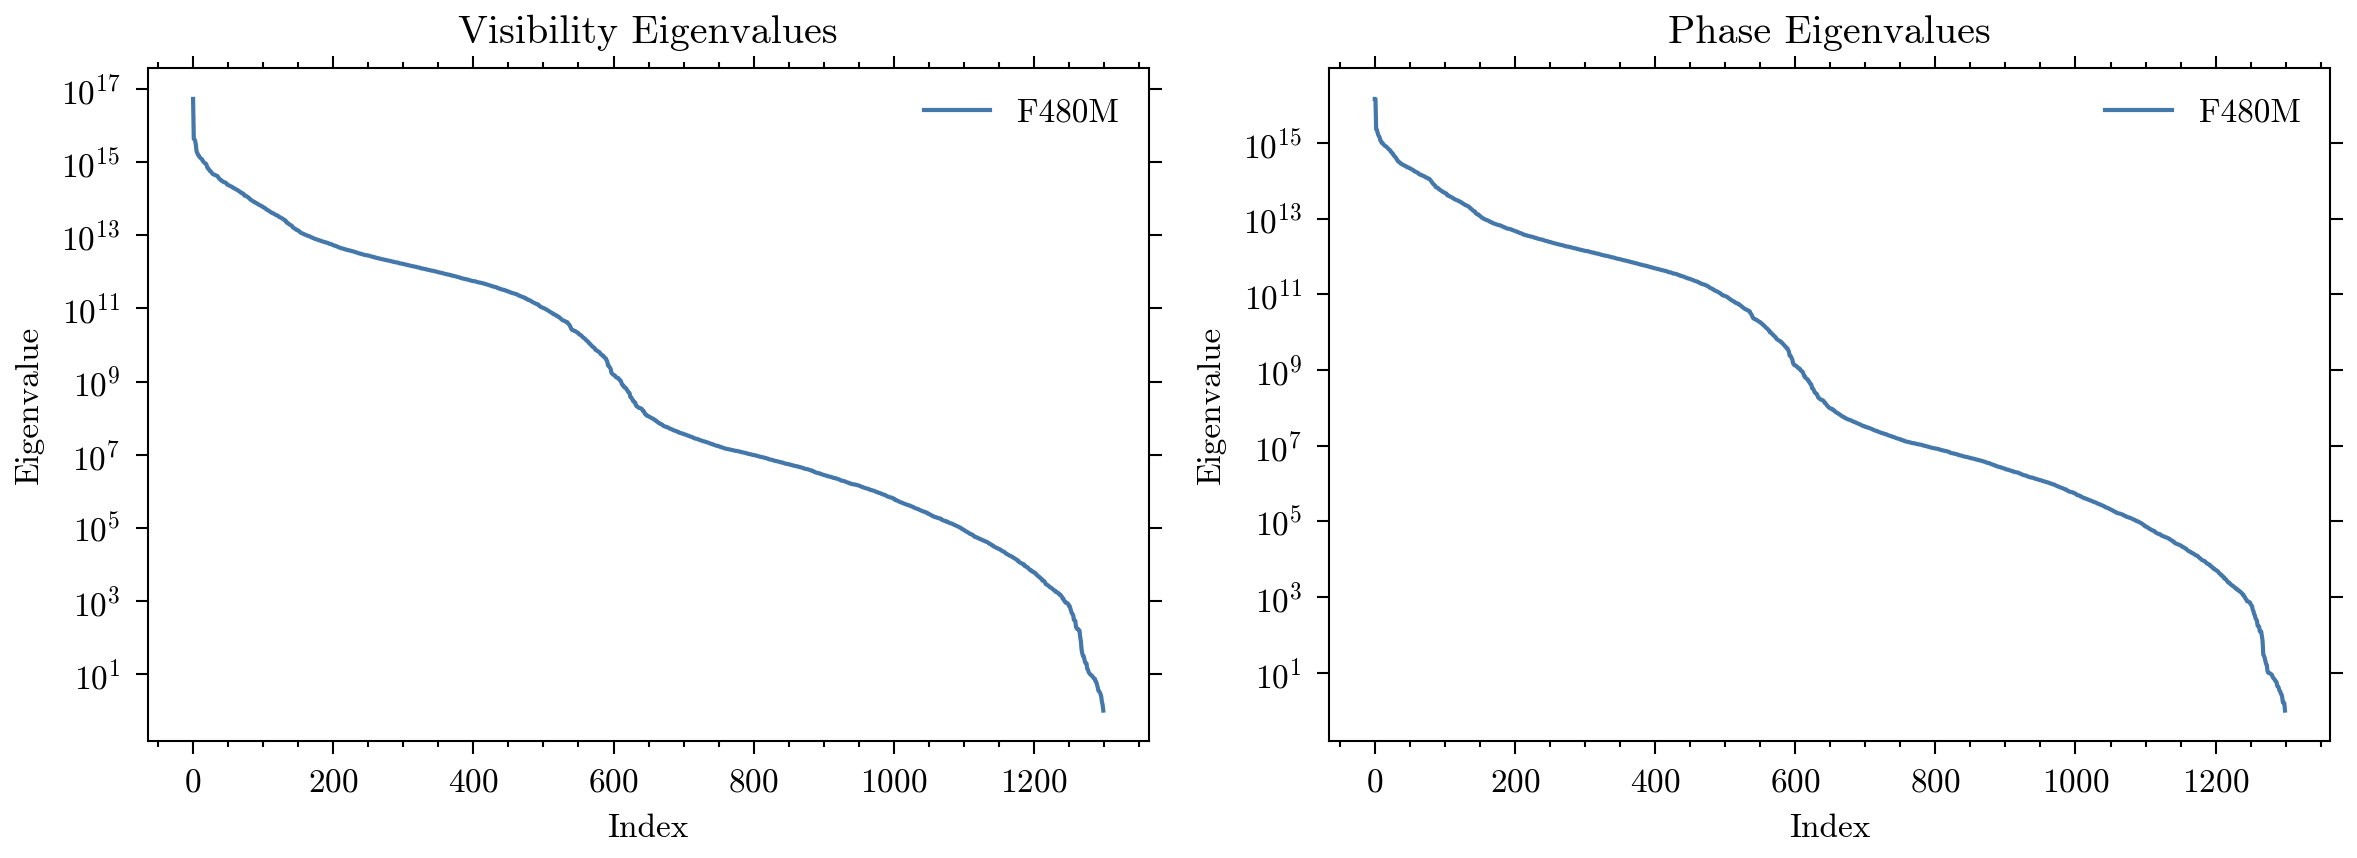

In [6]:
plt.figure(figsize=(8, 3))
ax1 = plt.subplot(1, 2, 1)
ax1.set(
    title="Visibility Eigenvalues", xlabel="Index", ylabel="Eigenvalue", yscale="log"
)

for filt in FILTERS:
    ax1.plot(outputs[filt]["amplitudes"]["eig_vals"], label=filt)
ax1.legend()

ax2 = plt.subplot(1, 2, 2)
ax2.set(title="Phase Eigenvalues", xlabel="Index", ylabel="Eigenvalue", yscale="log")

for filt in FILTERS:
    ax2.plot(outputs[filt]["phases"]["eig_vals"], label=filt)
ax2.legend()
plt.tight_layout()
plt.show()

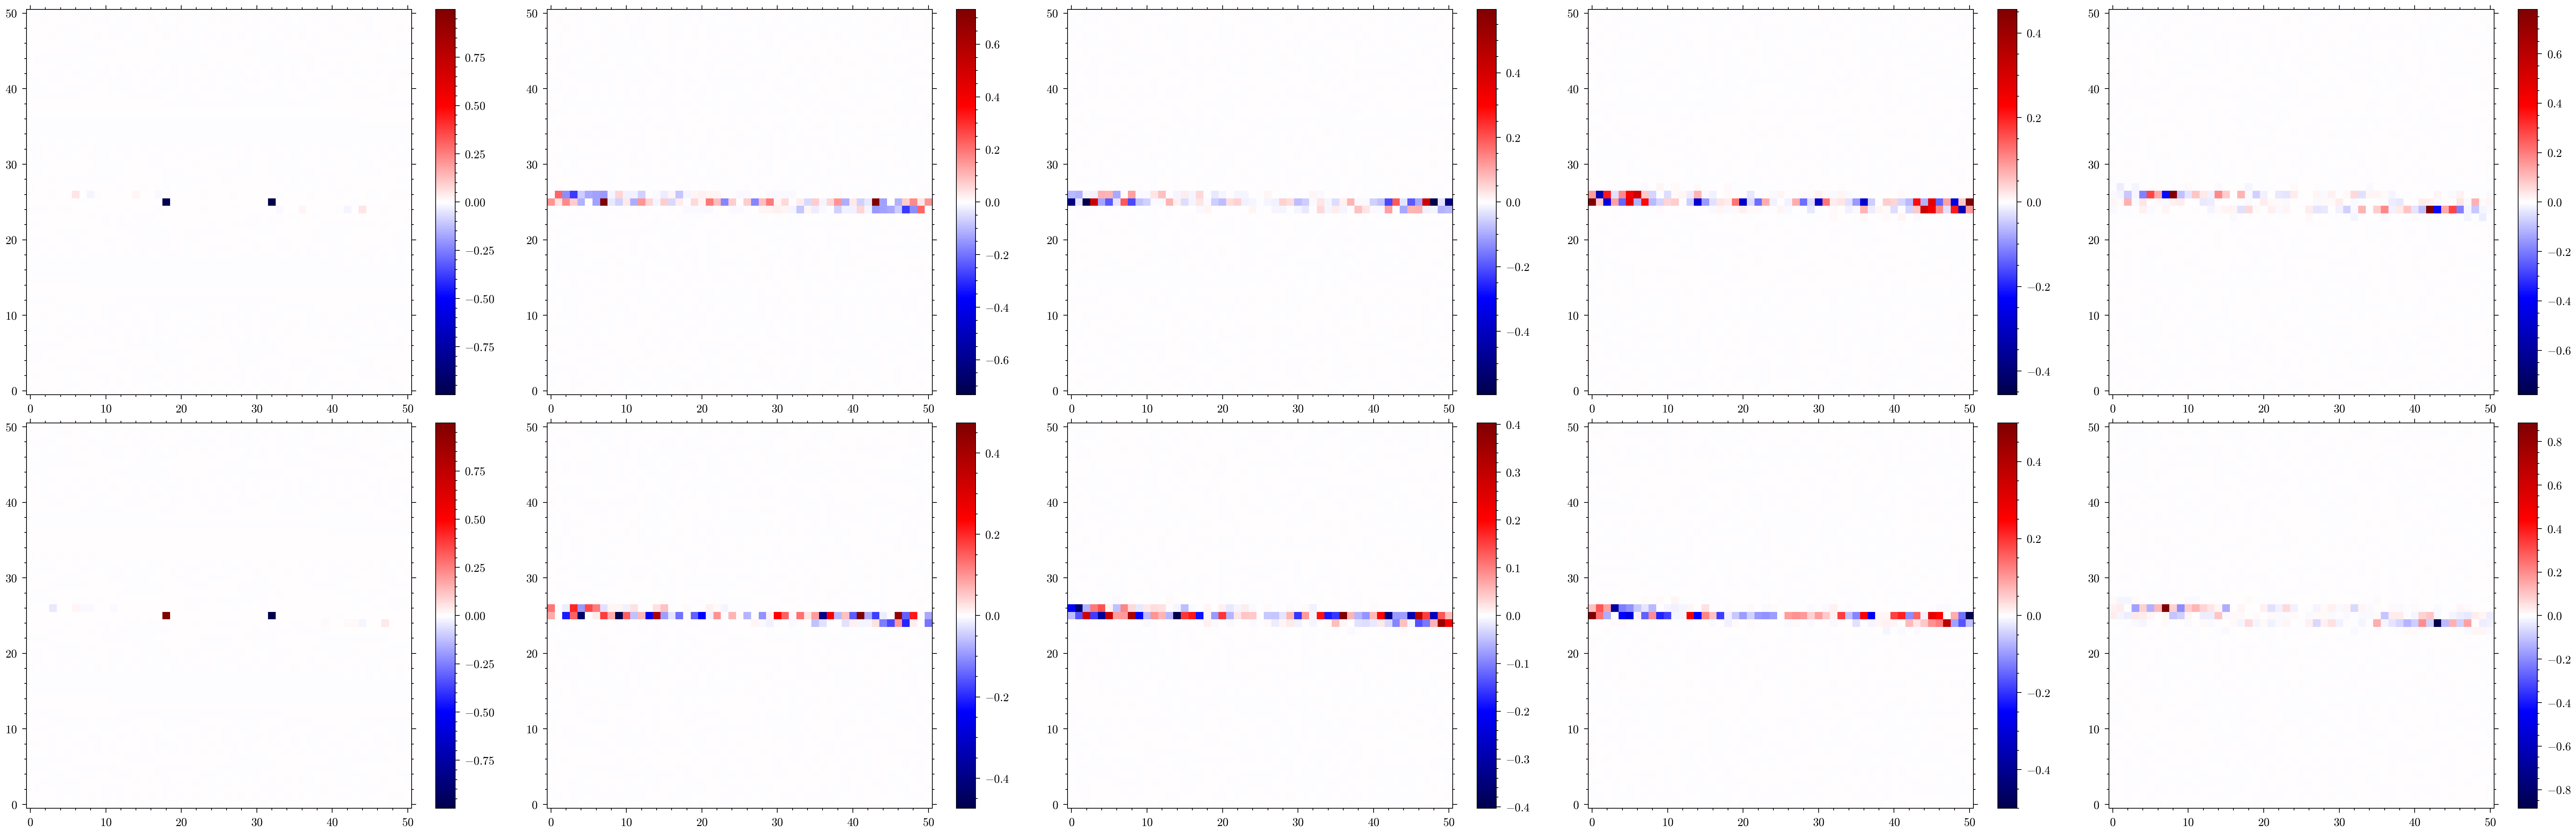

In [7]:
plt.figure(figsize=(25, 8))
for i in range(5):
    # log_amp, phase = np.array_split(eig_mats["F430M"][i], 2)
    log_amp = outputs["F480M"]["amplitudes"]["eig_vecs"][i]
    phase = outputs["F480M"]["phases"]["eig_vecs"][i]
    log_amp, phase = vis_to_im(log_amp, phase, (51, 51))

    v = np.nanmax(np.abs(log_amp))
    plt.subplot(2, 5, i + 1)
    plt.imshow(log_amp, seismic, vmin=-v, vmax=v)
    plt.colorbar()

    v = np.nanmax(np.abs(phase))
    plt.subplot(2, 5, i + 6)
    plt.imshow(phase, seismic, vmin=-v, vmax=v)
    plt.colorbar()

plt.tight_layout()
plt.show()

In [8]:
source_size = 99
fit_cals = False
fit_scis = False
fit_cals = True
# fit_scis = True
# level = 5
# # shearlets, shearletSystem = dorito.build_model.shearlet_prior(source_size, nScales=2)
# wavelets = dorito.wavelets.Wavelets(
#     np.ones((source_size, source_size)), level=level, wavelet="db2"
# )

dfnrnn_model = amigo.ramp_models.DFRNN(jr.key(0))
ramp_model = amigo.ramp_models.RNNRamp(
    dfnrnn_model, gain_model=amigo.detector_models.PixelSensitivity(), norm=2**14
)

# abbs = np.load(init_state_cache + "io_abs.npy", allow_pickle=True).item()
# state["aberrations"] = abbs

model, cal_fits, sci_fits = dorito.build_model.build_resolved_model(
    # model, params, cal_exposures, sci_exposures = dorito.build_model.build_resolved_model(
    cal_files[1:],
    # [],
    sci_files[5:],
    # cal_files,
    # sci_files,
    # [],
    state=state,
    source_size=source_size,
    rolls_dict=rolls,
    ramp_model=ramp_model,
    modeller=amigo.core_models.AmigoModel,
    # modeller=WaveletModel,
    # wavelets=wavelets,
    separate_fits=True,
    # cal_fit=dorito.model_fits.PointFit,
    cal_fit=dorito.model_fits.UniqueAbFit,
    # sci_fit=dorito.model_fits.DynamicResolvedFit,
    sci_fit=dorito.model_fits.ResolvedFit,
    rotate=False,
    # downsample=False,
    source_oversample=1,
)
fits = [*cal_fits, *sci_fits]


# This seems to fix some recompile issues
def fn(x):
    if isinstance(x, jax.Array):
        if "i" in x.dtype.str:
            return x
        return np.array(x, dtype=float)
    return x


model = jax.tree.map(fn, model)

In [9]:
pos_keys = []
spc_keys = []
for exp in fits:
    if not exp.calibrator:
        pos_keys.append(exp.map_param("positions"))
        spc_keys.append(exp.map_param("spectra"))


def kill_pos_grads(model, grads, args):
    # grads = grads.multiply(pos_keys, 0)
    grads = grads.multiply(pos_keys, 1e-3)
    grads = grads.multiply(spc_keys, 1e-2)
    return grads, args


eps = 1e1


def term_looper(looper, loss_dict):
    loss = np.array([v[-1] for v in loss_dict.values()]).mean(0)
    looper.set_description(f"Loss: {loss:.4e}")

    # if len(list(loss_dict.values())[0]) > 10:
    #     last_loss = np.array([v[-2] for v in loss_dict.values()]).mean(0)
    #     if np.abs(last_loss - loss) < eps:
    #         return True

    return False


def normalise_distribution(model_params, args):
    params = model_params.params
    if "log_distribution" in params.keys():
        for k, log_dist in params["log_distribution"].items():
            distribution = 10**log_dist
            params["log_distribution"][k] = np.log10(distribution / distribution.sum())

    if "spectra" in params.keys():
        spectra = jtu.map(
            lambda x: np.clip(x, a_min=-0.8, a_max=0.8), params["spectra"]
        )
        params["spectra"] = spectra

    return model_params.set("params", params), args


pscale = lambda model: model.optics.psf_pixel_scale / model.optics.oversample


def summarise_reconstruction(model, fits, result=None):

    ticks = [
        -0.5,
        0,
        0.5,
    ]

    flag = False
    for exp in fits:

        if not flag and exp.calibrator is False:
            try:
                dist = model.get_distribution(exp)
            except:
                dist = exp.get_distribution(model)

            fig, ax = plt.subplots(1, 2, figsize=(6, 2.3))

            c0 = dorito.plotting.plot_result(
                ax[0],
                dist,
                pixel_scale=pscale(model),
                roll_angle_degrees=-rolls[exp.filename],
                cmap="afmhot_10u",
                power=0.3,
                vmin=0,
                ticks=ticks,
            )

            c1 = dorito.plotting.plot_result(
                ax[1],
                dorito.misc.blur_distribution(dist, model, exp, factor=0.5),
                pixel_scale=pscale(model),
                cmap="afmhot_10u",
                power=0.3,
                vmin=None,
                roll_angle_degrees=-rolls[exp.filename],
                # model=hdb_final_model,
                ticks=ticks,
            )
            fig.colorbar(c1, ax=ax[1])

            fig.colorbar(c0)
            # pa = model.params["position_angles"][exp.key]
            ax[0].set_title(
                f"Io - {exp.filter}"  # - {model.params['position_angles'][exp.get_key('position_angles')]:.1f}deg"
            )
            ax[1].set(title=r"Convolved - $\lambda / 2D$")

            plt.tight_layout()
            # plt.savefig(output_path + f"{time}.png", dpi=300)
            # plt.close()
            plt.show()
            if type(sci_fits[0]) != dorito.model_fits.DynamicResolvedFit:
                flag = True

    try:
        amigo.plotting.plot_losses(result.losses[0], start=int(n_epoch * 0.75))
        amigo.plotting.plot(result.history)
    except:
        pass

    for exp in fits:
        exp.print_summary()

        if exp.ngroups > 2:
            amigo.plotting.summarise_fit(
                model,
                exp,
                # residuals=True,
            )

In [ ]:
cal_epoch = 350
n_epoch = 200

config = {
    "positions": sgd(4e-2, 0),
    "fluxes": sgd(2e-1, 0),
    "aberrations": sgd(3e-2, 4),
    "spectra": sgd(3e-2, 10),
    "log_distribution": adam(5e-2, 20),  # , (10, 0.25), b1=0.7),
    # "log_distribution": adam(7e-2, 0),  # , (10, 0.25), b1=0.7),,
    # "approx": adam(1e-5, 0),
    # "details": adam(6e-9, 15),
}


trainer = amigo.fitting.Trainer(
    loss_fn=dorito.stats.regularised_loss_fn,
    norm_fn=normalise_distribution,
    grad_fn=kill_pos_grads,
    cache=fisher_cache,
    looper_fn=term_looper,
)

trainer = trainer.update_fishers(
    model.set("detector.ramp.bleed", False),
    # model,
    fits,
    # args=args,
    verbose=True,
    parameters=[
        "positions",
        "fluxes",
        "aberrations",
        "spectra",
        # "one_on_fs",
        # "log_distribution",
        # "spectral_coeffs",
    ],
    # recalculate=True,
)

if fit_cals:
    print("Fitting calibrator targets")
    cal_result = trainer.train(
        model=model,
        optimisers={k: v for k, v in config.items() if k != "log_distribution"},
        epochs=cal_epoch,
        batches=cal_fits,
        # args=args,
    )

    summarise_reconstruction(cal_result.model, cal_fits, result=cal_result)
    np.save(init_state_cache + "wr137_abs.npy", cal_result.model.params["aberrations"])


if fit_scis:
    print("Fitting science targets")
    result = trainer.train(
        model=model,
        optimisers=config,
        epochs=n_epoch,
        batches=sci_fits,
        args=args,
    )

    summarise_reconstruction(result.model, sci_fits, result=result)


# balance = dorito.stats.prior_data_balance(result.model, fits[-1], args)
# print(f"Likelihood: {balance[0]:.3e}, Prior: {balance[1]:.3e}")

  0%|          | 0/8 [00:00<?, ?it/s]

Fitting calibrator targets


  0%|          | 0/350 [00:00<?, ?it/s]

Compiling Loss function...
Compiling update function...

Initial_loss Loss: 4,569,171.23
Estimated run time: 0:03:24


In [ ]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [ ]:
import planetmapper
import scipy

features = {
    "seth": (132, -5.3),  # long [deg], lat [deg]
    # "masubi": (--56.18, -49.6),
    "P197": (108.8, -47.3),
    "masubi": (52.6, -45),
    "leizi": (44.93, 13.48),
    # "leizi": (-315.074, 13.48),
    "amirani": (115.2, 24.0),
    # "subobs": (--107.57361768, 2.60587485),
}
# https://iopscience.iop.org/article/10.3847/PSJ/ad4346/pdf


def plot_io_with_ephemeris(
    ax,
    array,
    exp,
    data_dir,
    pixel_scale,
    roll_angle_degrees=0.00,
    legend=False,
    points=None,
    **kwargs
):

    body = planetmapper.Observation(data_dir + exp.filename[:-5] + "_nis_uncal.fits")
    if points is not None:
        body.coordinates_of_interest_lonlat = points

    def coordinate_func(ra, dec):
        x, y = body.radec2angular(ra, dec)
        return -x, y

    body.plot_wireframe_custom(
        # body.plot_wireframe_angular(
        ax,
        coordinate_func=coordinate_func,
        # aspect_adjustable="box",
        add_title=False,
        label_poles=True,
        indicate_equator=True,
        indicate_prime_meridian=True,
        grid_interval=30,
        grid_lat_limit=75,
        formatting={
            # "limb": {
            #     "linestyle": "--",
            #     "linewidth": 0.8,
            #     "alpha": 0.8,
            #     "color": "white",
            # },
            "grid": {
                "linestyle": "--",
                "linewidth": 0.5,
                "alpha": 0.3,
                "color": "k",
            },
            "equator": {
                "color": "r",
                "linewidth": 1,
                "color": "r",
                "label": "equator",
                # "alpha": 0.0,
            },
            "terminator": {
                "linewidth": 1,
                "linestyle": "-",
                "color": "aqua",
                "alpha": 0.0,
                "label": "terminator",
            },
            "coordinate_of_interest_lonlat": {
                "color": "gold",
                "marker": "^",
                "facecolors": "none",
                # "markeredgecolor": "red",
                "s": 10,
                "label": "volcano",
            },
            "limb_illuminated": {"color": "b", "alpha": 0.0},
        },
    )

    if legend:
        handles, labels = plt.gca().get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        plt.legend(
            by_label.values(),
            by_label.keys(),
            loc="upper left",
        )

    im = plot_result(
        ax,
        array,
        pixel_scale=pixel_scale,
        roll_angle_degrees=roll_angle_degrees,
        show_diff_lim=True,
        **kwargs,
    )

    return im


def plot_result(
    ax,
    array,
    pixel_scale,
    roll_angle_degrees: float = 0.0,
    model=None,
    show_diff_lim: bool = True,
    cmap: str = "afmhot_10u",
    bg_color: str = "k",
    axis_labels: dict = {
        "xlabel": r"$\Delta$RA [arcsec]",
        "ylabel": r"$\Delta$DEC [arcsec]",
    },
    vmin: float = 0.0,
    vmax: float = None,
    power=0.5,
    contour=False,
    scale=1.0,
    translate=(0.0, 0.0),
):
    rotation_transform = (
        mpl.transforms.Affine2D()
        .translate(*translate)
        .rotate_deg(roll_angle_degrees)
        .scale(scale)
    )  # Create a rotation transformation

    ax.set_facecolor(bg_color)  # Set the background colour
    ax.tick_params(direction="out")
    ax.set(
        xticks=[0.5, 0, -0.5],
        yticks=[-0.5, 0, 0.5],
        **axis_labels,
    )  # Set the axis labels
    if model is not None:
        pixel_scale = model.psf_pixel_scale / model.optics.oversample / scale
        if show_diff_lim:
            ax = dorito.plotting.plot_diffraction_limit(model, ax, OOP=True)

    kwargs = {
        "cmap": cmap,
        "extent": dorito.plotting.get_arcsec_extents(pixel_scale / scale, array.shape),
        "norm": mpl.colors.PowerNorm(power, vmin=vmin, vmax=vmax),
        "aspect": "equal",
    }
    if contour:
        im = ax.contour(
            array,
            linewidths=0.5,
            levels=array.max() * np.linspace(0, 1, 10) ** 2,
            **kwargs,
        )
    else:
        im = ax.imshow(array, interpolation="bilinear", **kwargs)

    ax.axis("equal")
    trans_data = rotation_transform + ax.transData  # creating transformation
    im.set_transform(trans_data)  # applying transformation to image

    return im


def compute_com_physical(array, pixel_scale):
    """
    Compute the center of mass of a 2D array, assuming the center of the array is at (0, 0).

    Parameters:
    - array: 2D numpy array representing the mass distribution.
    - pixel_scale: The physical scale of each pixel (e.g., in units per pixel).

    Returns:
    - com_physical: The center of mass in physical coordinates, assuming (0, 0) at the center of the array.
    """
    # Compute the center of mass in pixel indices
    com_index = np.array(scipy.ndimage.center_of_mass(numpy.array(array)))

    # Calculate the center of the array in pixel indices
    array_center = np.array(array.shape) / 2 - 0.5  # (rows/2 - 0.5, cols/2 - 0.5)

    # Convert to physical coordinates
    com_physical = (com_index - array_center) * pixel_scale

    return np.array(
        [-com_physical[1], com_physical[0]]
    )  # Return (x, y) in physical coordinates

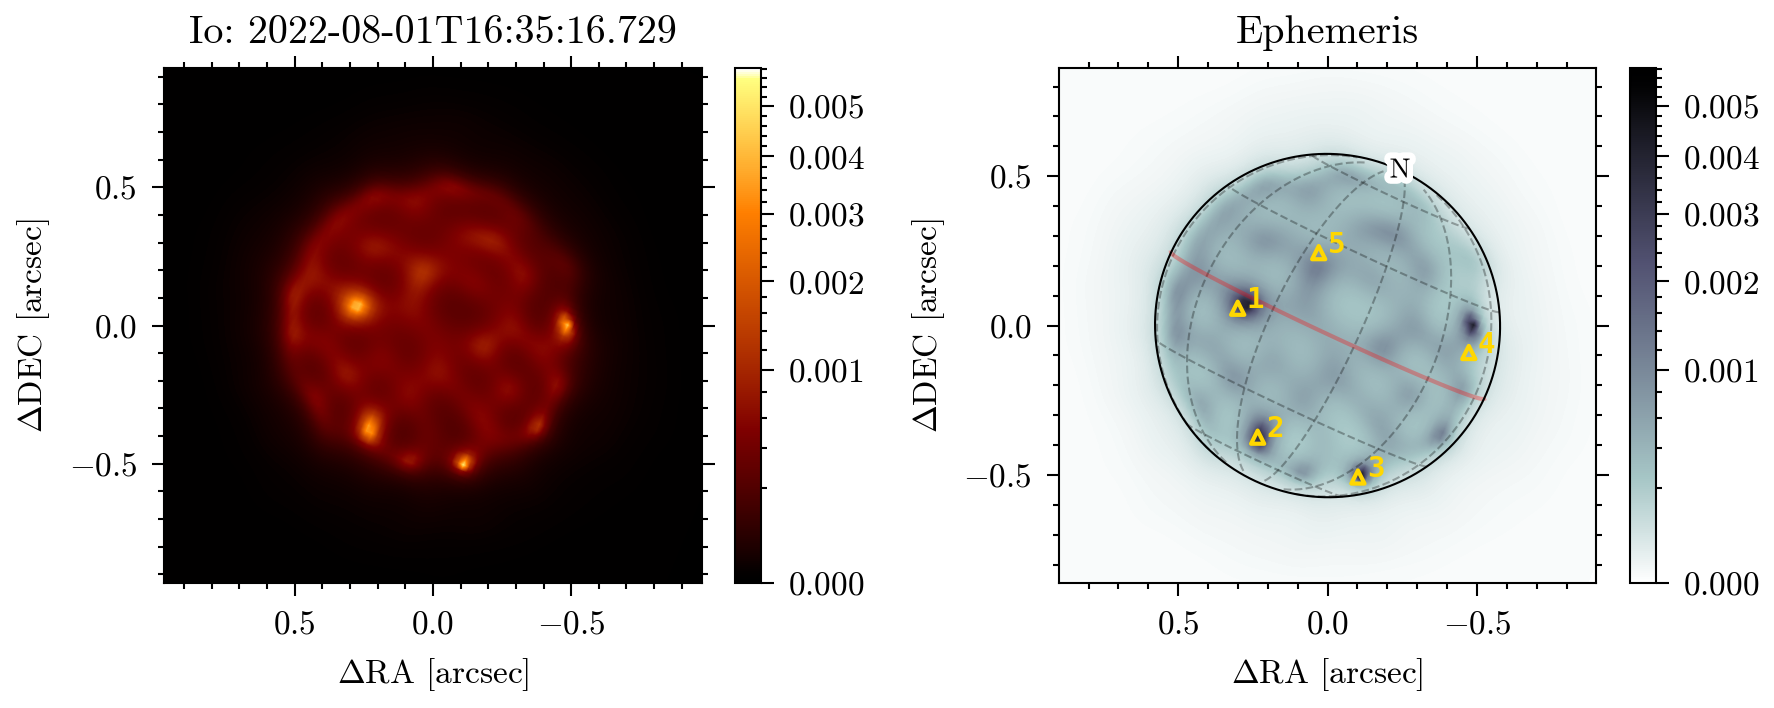

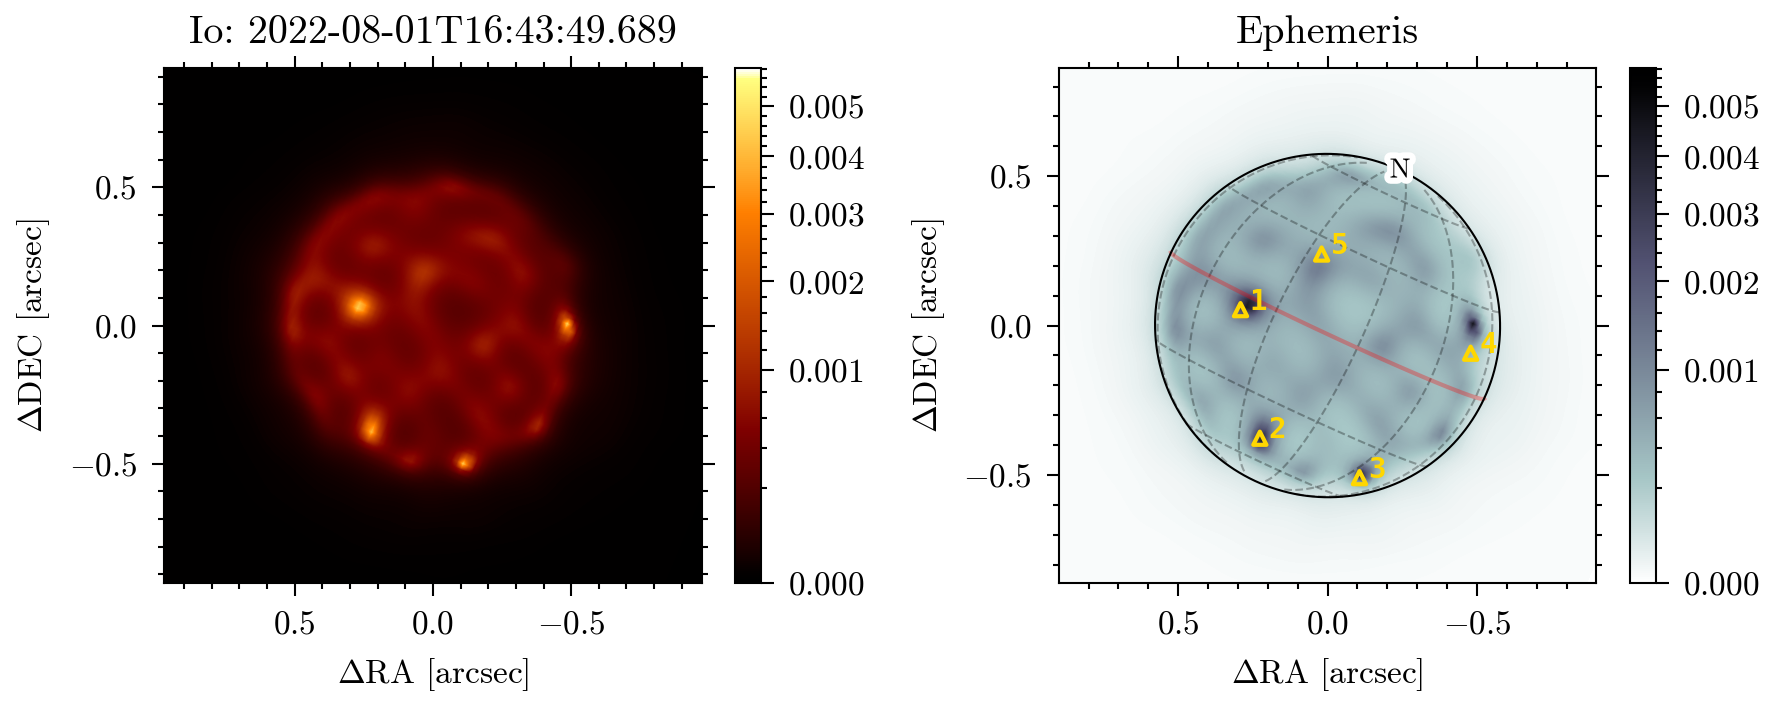

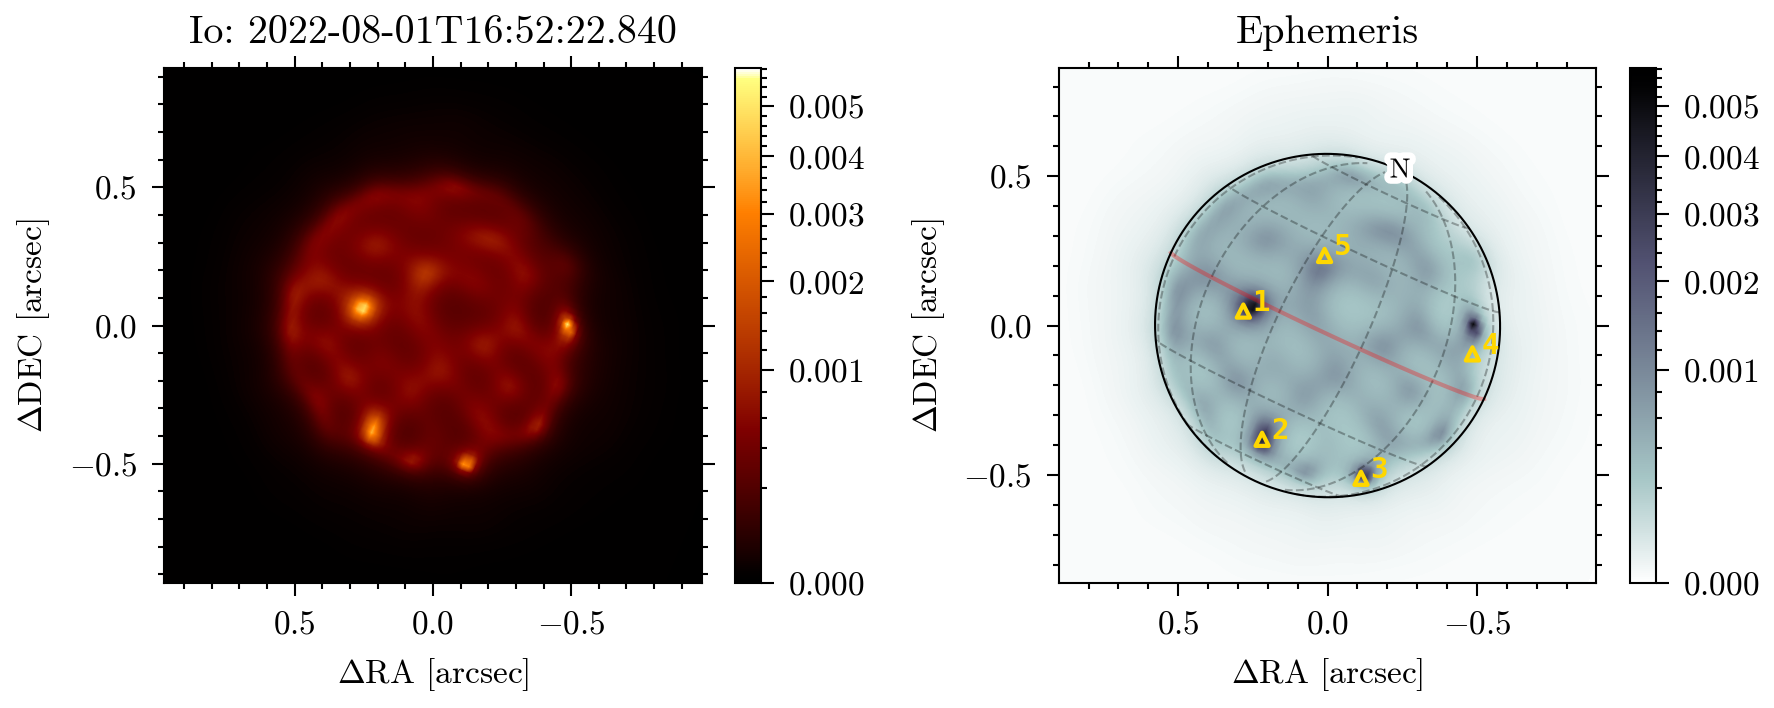

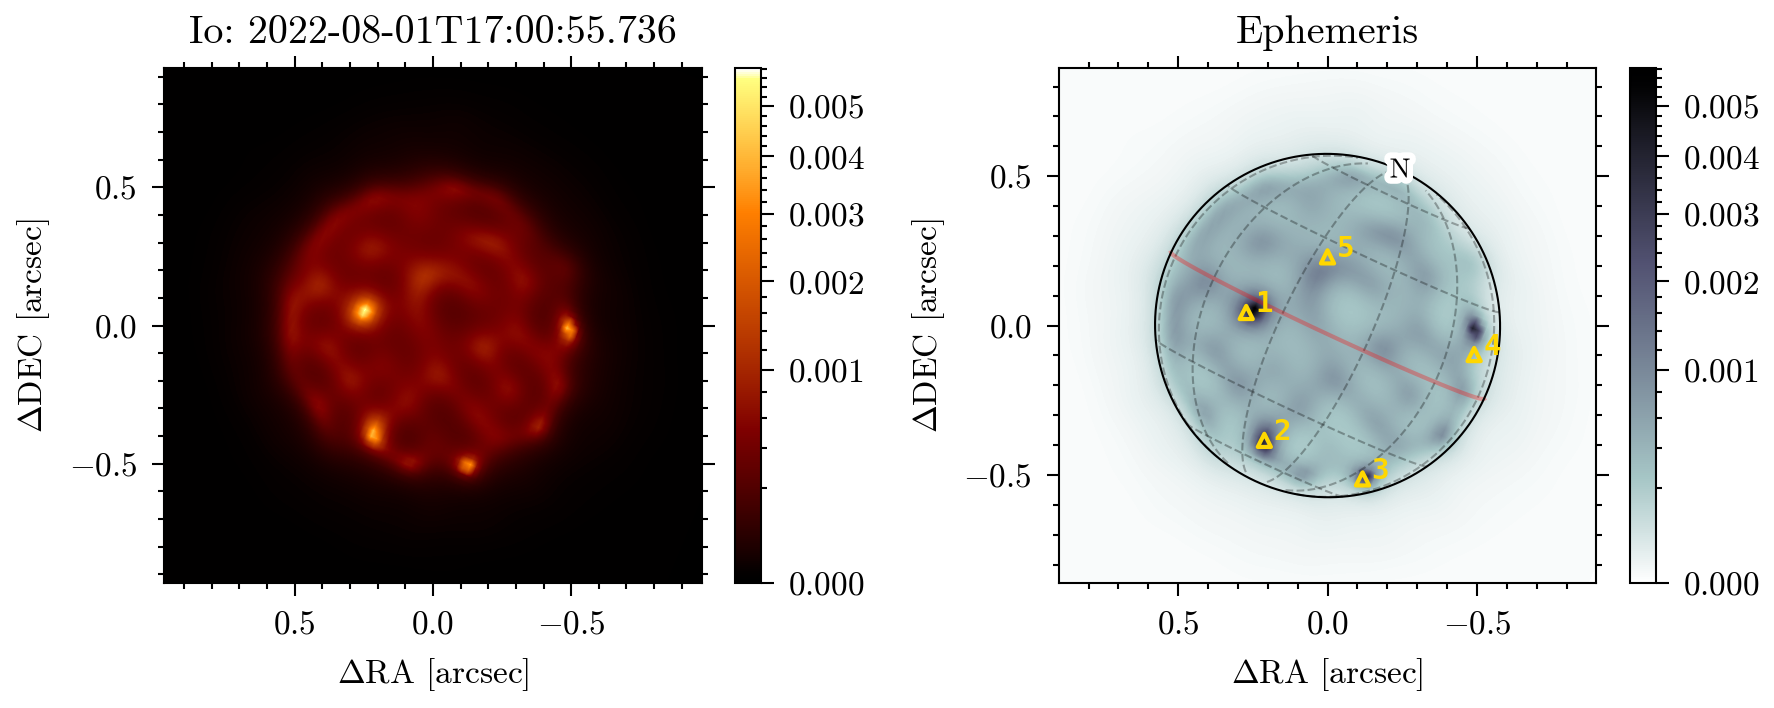

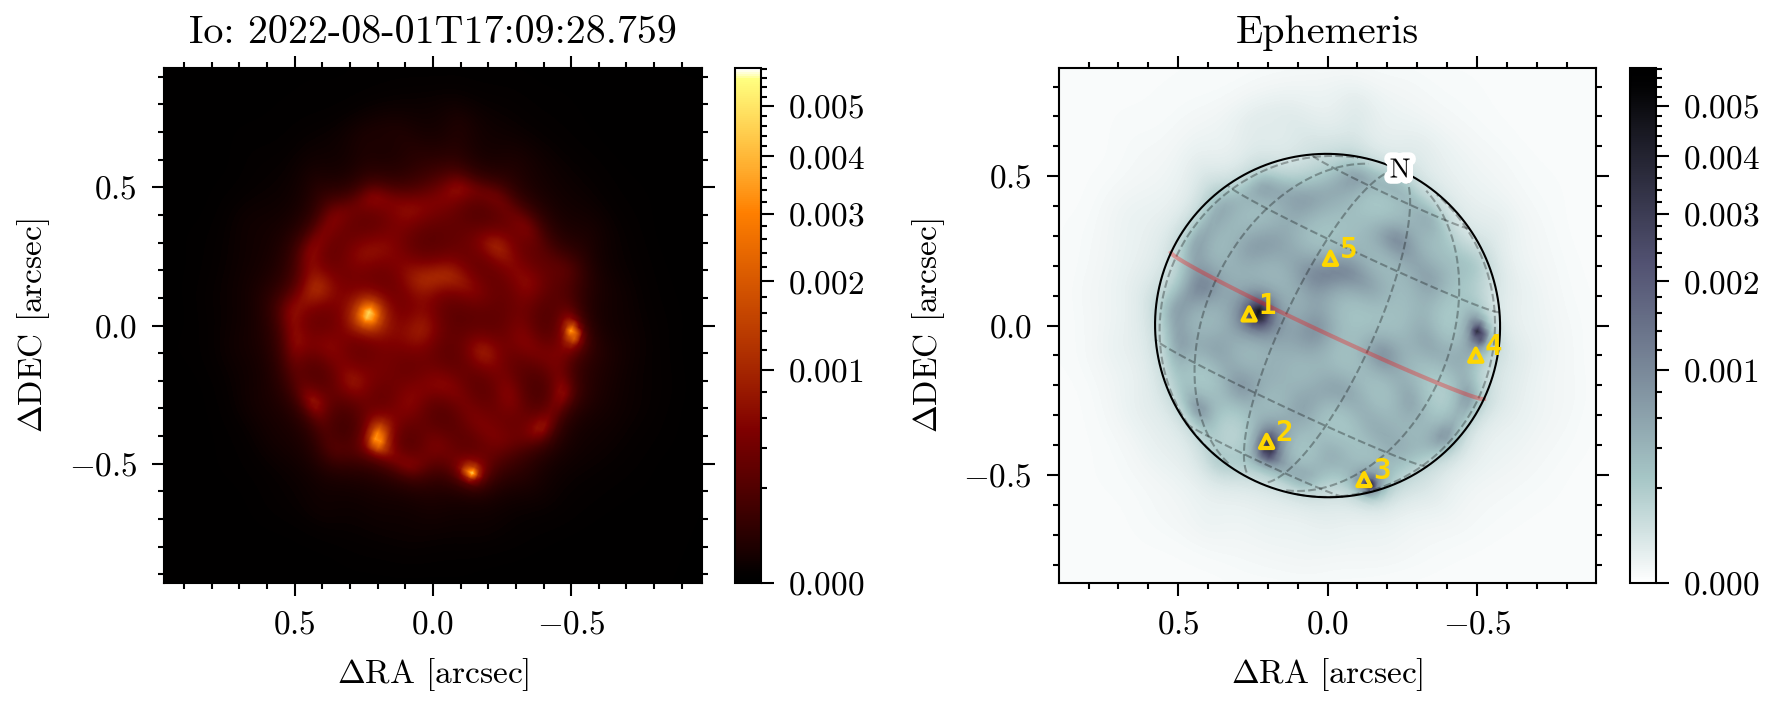

In [ ]:
# from planetmapper.kernel_downloader import download_urls

# download_urls("https://naif.jpl.nasa.gov/pub/naif/generic_kernels/lsk/")
# download_urls("https://naif.jpl.nasa.gov/pub/naif/generic_kernels/pck/")
# download_urls(
#     "https://naif.jpl.nasa.gov/pub/naif/generic_kernels/spk/satellites/jup365.bsp"
# )
# download_urls("https://naif.jpl.nasa.gov/pub/naif/JWST/kernels/spk/")


result_model = result.model


io_peak_flux = np.array([result_model.get_distribution(exp) for exp in sci_fits]).max()
clip_value = 0.001

save_dir = "gifs/spinning_io/"
for exp, file in zip(sci_fits, sci_files):

    dist = result_model.get_distribution(exp)

    time = astropy.time.Time(file[0].header["EXPMID"], format="mjd").isot
    center = compute_com_physical(
        np.clip(dist, min=0, max=clip_value),
        result_model.psf_pixel_scale / result_model.oversample,
    )

    fig, ax = plt.subplots(1, 2, figsize=(6, 2.5))
    c0 = plot_result(
        ax[0],
        dist,
        pixel_scale=result_model.psf_pixel_scale / result_model.oversample,
        cmap="afmhot_u",
        vmax=io_peak_flux,
        power=0.5,
        roll_angle_degrees=-rolls[exp.filename],
        translate=-center,
        scale=source_size / 75.0,
    )

    c1 = plot_io_with_ephemeris(
        ax[1],
        dist,
        pixel_scale=result_model.psf_pixel_scale / result_model.oversample,
        cmap="bone_ur",
        exp=exp,
        data_dir=uncal_path,
        vmax=io_peak_flux,
        points=list(features.values()),
        # contour=True,
        bg_color="white",
        power=0.5,
        translate=-center,
        roll_angle_degrees=-rolls[exp.filename],
        scale=source_size / 75.0,
    )

    # Labelling volcanoes
    coords = []
    for artist in ax[1].collections:
        if hasattr(artist, "get_offsets"):
            coord = artist.get_offsets()[0]
            coords.append(coord)

    eps = 3e-2
    for i, (x, y) in enumerate(coords):  # i should now correctly track the index
        ax[1].text(
            x - eps,
            y,
            f"{i+1}",
            fontsize=7,
            c="gold",
            fontfamily="monospace",
            fontweight="bold",
        )  # Use i in the label

    fig.colorbar(c0)
    ax[0].set_title(f"Io: {time}")
    ax[1].set_title(f"Ephemeris")
    plt.tight_layout()
    fig.colorbar(c1, ax=ax[1])
    # plt.savefig(output_path + f"{time}.png", dpi=300)
    # plt.close()
    plt.show()

In [ ]:
# formats = [
#     "jd",
#     "mjd",
#     "decimalyear",
#     "unix",
#     "unix_tai",
#     "cxcsec",
#     "gps",
#     "plot_date",
#     "stardate",
#     "datetime",
#     "ymdhms",
#     "iso",
#     "isot",
#     "yday",
#     "datetime64",
#     "fits",
#     "byear",
#     "jyear",
#     "byear_str",
#     "jyear_str",
# ]

# time = astropy.time.Time(file[0].header["EXPMID"], format="mjd")

# list(time.ymdhms)[-3:]


# def convert_time(time):

#     if type(time) == str:
#         time = astropy.time.Time(str(time, format="mjd"))

#     t = list(time.ymdhms)[-3:]

#     return f"{t[0]:02d}h {t[1]:02d}m {t[2]:.0f}s"


# # convert_time(rang[0])

In [ ]:
def get_exposing(files, eps=1e0, samples=1e4):

    starts = []
    ends = []
    for file in files:

        # print(file[0].header)
        start = astropy.time.Time(file[0].header["EXPSTART"], format="mjd")
        end = astropy.time.Time(file[0].header["EXPEND"], format="mjd")

        starts.append(mins_past_the_hour(start.mjd))
        ends.append(mins_past_the_hour(end.mjd))

    starts = np.array(starts)
    ends = np.array(ends)
    rang = np.linspace(starts.min() - eps, ends.max() + eps, int(samples))

    exposings = np.array(
        [
            np.where(rang > start, 1.0, 0.0) * np.where(rang < end, 1.0, 0.0)
            for start, end in zip(starts, ends)
        ]
    )

    return rang, exposings


def mins_past_the_hour(mjd):
    # Reference time: 5:00 PM (17:00) on August 1st, 2022 UTC
    ref_time = astropy.time.Time("2022-08-01 16:00:00", format="iso", scale="utc")

    # Convert input MJD to an astropy Time object
    current_time = astropy.time.Time(mjd, format="mjd", scale="utc")

    # Compute time difference in minutes
    delta_minutes = (current_time - ref_time).to("min").value

    return delta_minutes

/tmp/ipykernel_756793/3377626479.py:9: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


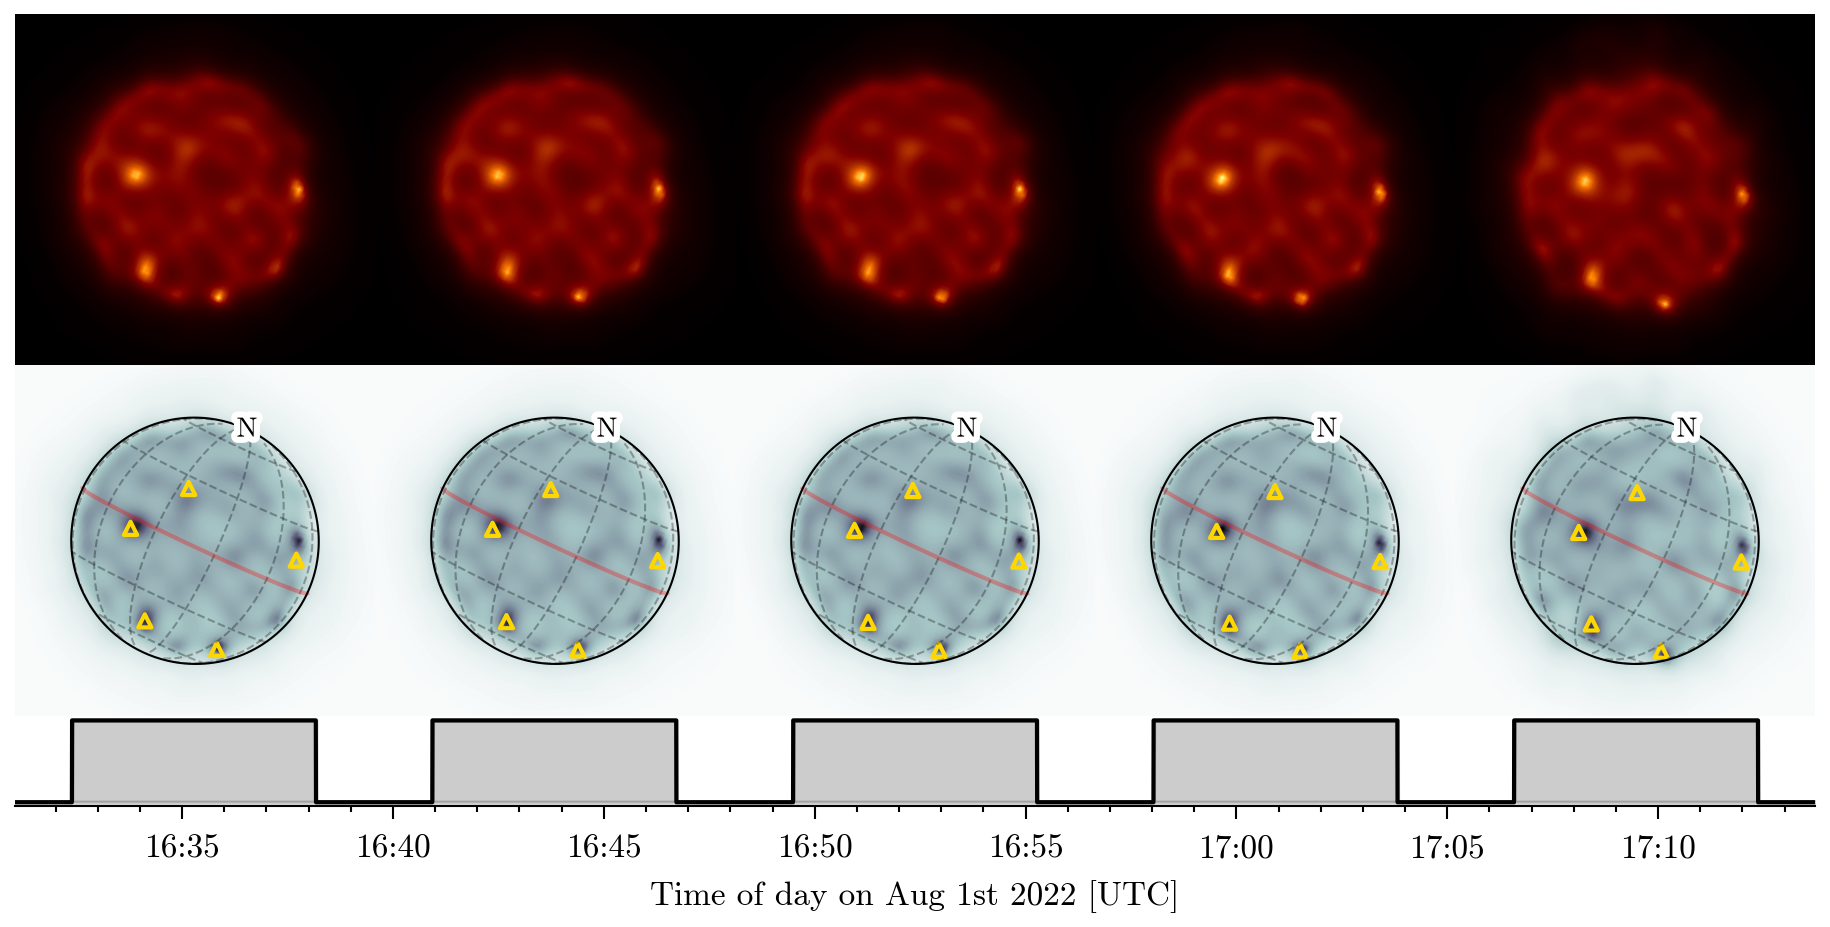

In [ ]:
%matplotlib inline

rang, exposings = get_exposing(sci_files, eps=1.35)
exposing = np.sum(exposings, axis=0)

fig, axes = plt.subplots(2, 5, figsize=(6, 3), gridspec_kw={"hspace": 0.0, "wspace": 0.0, "left":0, "right":1.})

# Adjust layout first
plt.tight_layout()

fig.subplots_adjust(bottom=0.1)  # Shift everything up to leave space for time axis

# Create a new axes for the time plot — [left, bottom, width, height] in figure fraction
time_ax = fig.add_axes([0., 0.0, 1., .1])  # Tune values if needed

for col, exp, file in zip(range(len(sci_fits)), sci_fits, sci_files):

    axes[0][col].axis("off")
    axes[1][col].axis("off")

    dist = result_model.get_distribution(exp)

    time = astropy.time.Time(file[0].header["EXPMID"], format="mjd")
    center = compute_com_physical(
        np.clip(dist, min=0, max=clip_value),
        result_model.psf_pixel_scale / result_model.oversample,
    )

    # axes[0][col].set(title=convert_time(time))

    c0 = plot_result(
        axes[0][col],
        dist,
        pixel_scale=result_model.psf_pixel_scale / result_model.oversample,
        cmap="afmhot_u",
        vmax=io_peak_flux,
        power=0.5,
        roll_angle_degrees=-rolls[exp.filename],
        translate=-center,
        scale=source_size / 75.0,
    )

    c1 = plot_io_with_ephemeris(
        axes[1][col],
        dist,
        pixel_scale=result_model.psf_pixel_scale / result_model.oversample,
        cmap="bone_ur",
        exp=exp,
        data_dir=uncal_path,
        vmax=io_peak_flux,
        points=list(features.values()),
        # contour=True,
        bg_color="white",
        power=0.5,
        translate=-center,
        roll_angle_degrees=-rolls[exp.filename],
        scale=source_size / 75.0,
    )

    # Labelling volcanoes
    coords = []
    for artist in ax[1].collections:
        if hasattr(artist, "get_offsets"):
            coord = artist.get_offsets()[0]
            coords.append(coord)

    # eps = 3e-2
    # for i, (x, y) in enumerate(coords):  # i should now correctly track the index
    #     axes[1][col].text(
    #         x - eps,
    #         y,
    #         f"{i+1}",
    #         fontsize=7,
    #         c="gold",
    #         fontfamily="monospace",
    #         fontweight="bold",
    #     )  # Use i in the label

time_ax.plot(rang, exposing, 'k')
time_ax.fill_between(rang, exposing, color='k', alpha=0.2)
time_ax.spines['top'].set_visible(False)
time_ax.spines['right'].set_visible(False)
time_ax.spines['left'].set_visible(False)
time_ax.tick_params(axis="x", which="both", top=False)
time_ax.set(
    xlim=(rang.min(), rang.max()),
    xlabel="Time of day on Aug 1st 2022 [UTC]",  # Set the x-axis label
    xticks=range(35, 75, 5),
    xticklabels=["16:35", "16:40", "16:45", "16:50", "16:55", "17:00", "17:05", "17:10"],
    yticks=[],
    )


    # time_ax.axis("off")

plt.show()

# plt.show()

In [ ]:
def lcurve_sweep(
    regulariser: str,  # e.g. "L1", "L2", "TV", "QV", "ME", "SF"
    coeffs,
    reg_func_dict,
    trainer,
    model,
    optimisers,
    epochs,
    exposures,
):
    """
    Function to find an optimal regularisation hyperparameter using the l-curve method.
    """

    @zdx.filter_jit
    def calc_balance(model, exposures, args, coeff):
        return np.array(
            [
                dorito.stats.prior_data_balance(model, exp, args, coeff)
                for exp in exposures
            ]
        ).sum(0)

    balances = []
    results = []

    args = {"reg_dict": {regulariser: None}, "reg_func_dict": reg_func_dict}

    for coeff in coeffs:
        print(f"Regulariser: {regulariser}, Coefficient: {coeff:.2e}")

        args["reg_dict"][regulariser] = coeff

        result = trainer.train(
            model=model,
            optimisers=optimisers,
            epochs=epochs,
            batches=exposures,
            args=args,
        )

        balance = calc_balance(result.model, exposures, args, coeff)
        balances.append(balance)

        results.append(result)

    return results, np.array(balances).T

In [ ]:
coeffs = np.logspace(-5, 6, 12)

results, balances = lcurve_sweep(
    "TV",
    coeffs,
    {"TV": dorito.stats.TV},
    trainer=trainer,
    model=model,
    optimisers=config,
    epochs=n_epoch,
    exposures=fits,
)

for res, coeff in zip(results, coeffs):
    print(f"{coeff:.2e}")
    summarise_reconstruction(res.model, fits, result=res)

Regulariser: TV, Coefficient: 1.00e-05


  0%|          | 0/500 [00:00<?, ?it/s]

Compiling Loss function...
Compiling update function...

Initial_loss Loss: 191,204,641.20
Estimated run time: 0:10:15
Full Time: 0:11:38
Final Loss: 302,252.21
Regulariser: TV, Coefficient: 1.00e-04


  0%|          | 0/500 [00:00<?, ?it/s]

Compiling Loss function...
Compiling update function...

Initial_loss Loss: 191,204,641.20
Estimated run time: 0:10:21
Full Time: 0:11:41
Final Loss: 302,252.21
Regulariser: TV, Coefficient: 1.00e-03


...

  0%|          | 0/500 [00:00<?, ?it/s]

Compiling Loss function...
Compiling update function...

Initial_loss Loss: 191,206,044.19
Estimated run time: 0:10:26
Full Time: 0:11:40
Final Loss: 314,484.18
Regulariser: TV, Coefficient: 1.00e+06


  0%|          | 0/500 [00:00<?, ?it/s]

Compiling Loss function...
Compiling update function...

Initial_loss Loss: 191,218,671.10
Estimated run time: 0:10:24
Full Time: 0:11:45
Final Loss: 397,839.39
1.00e-05


NameError: name 'summarise_reconstruction' is not defined

1.00e-05


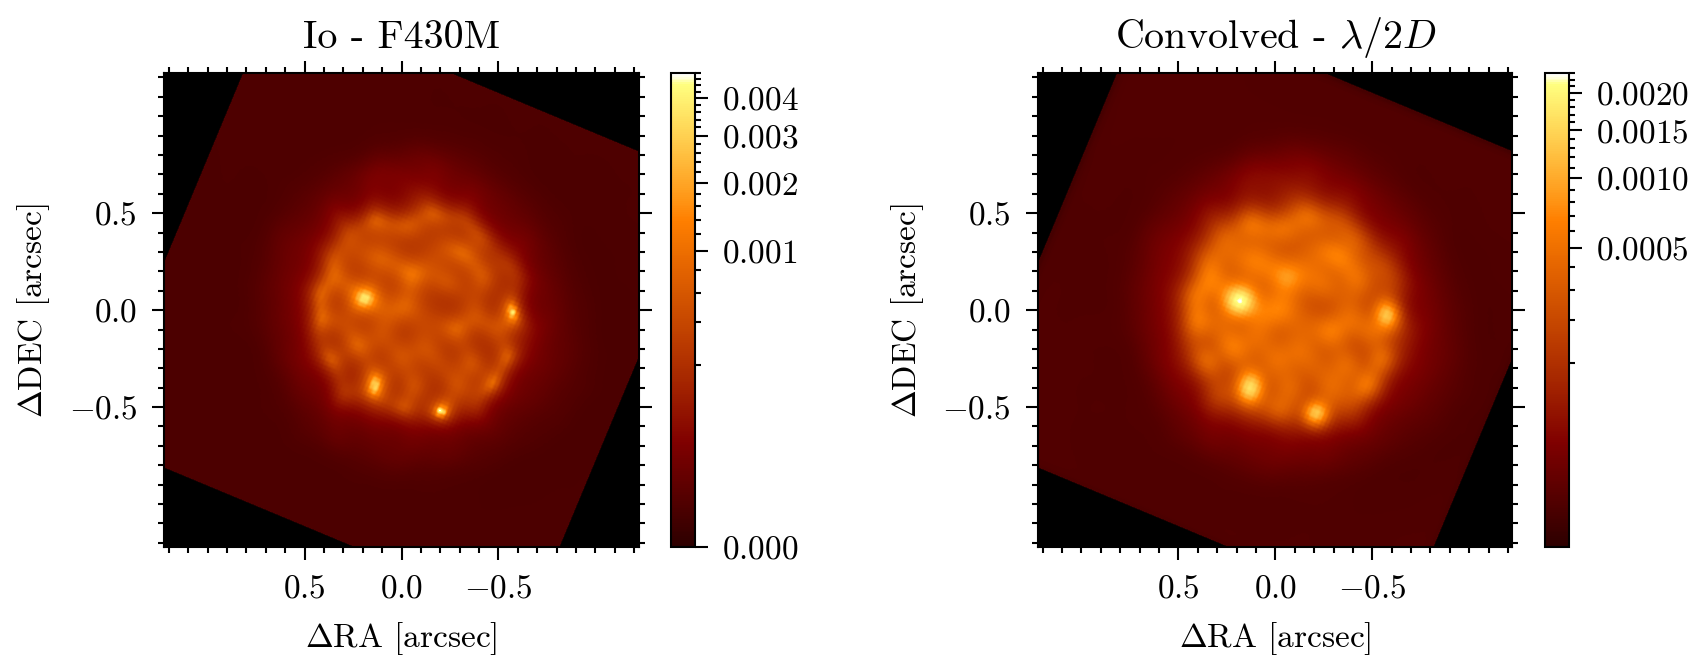

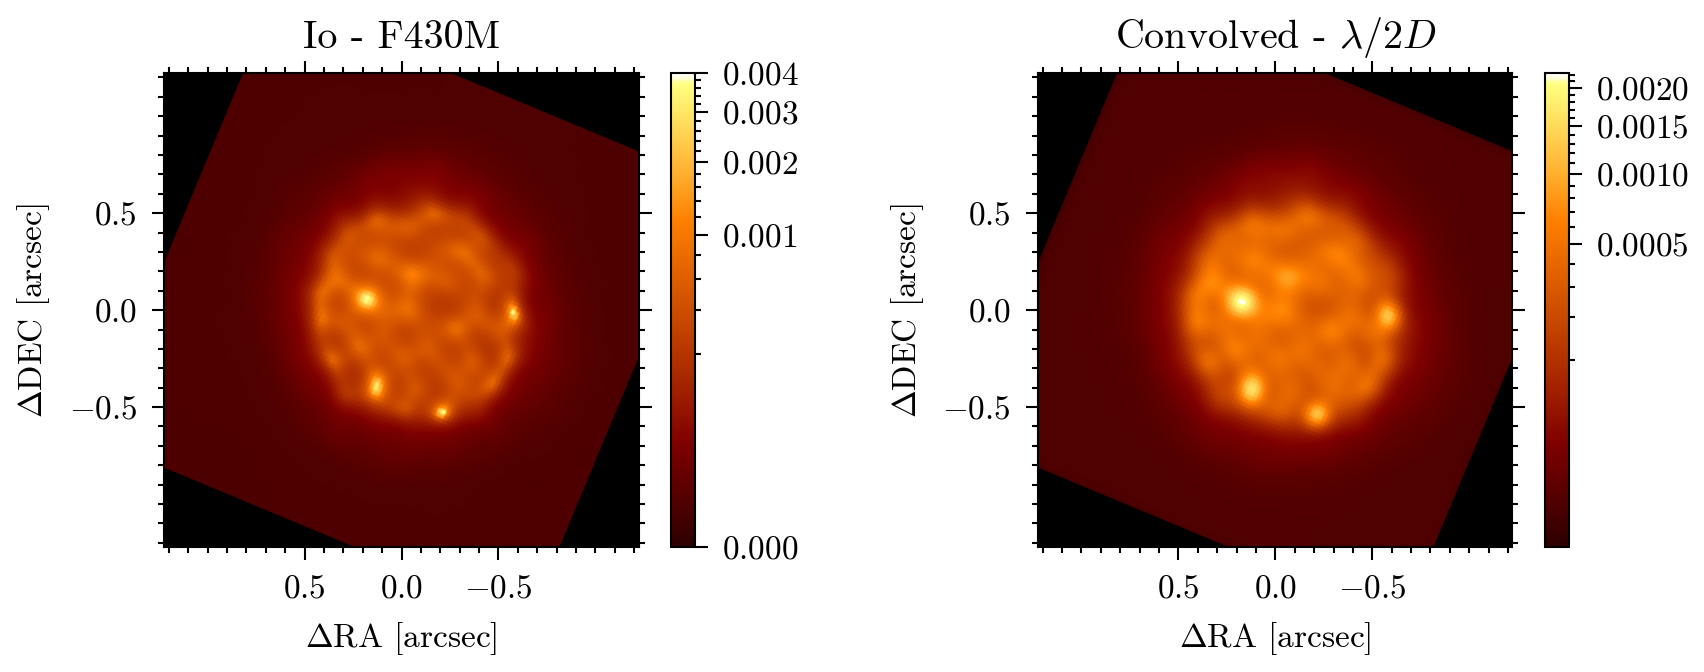

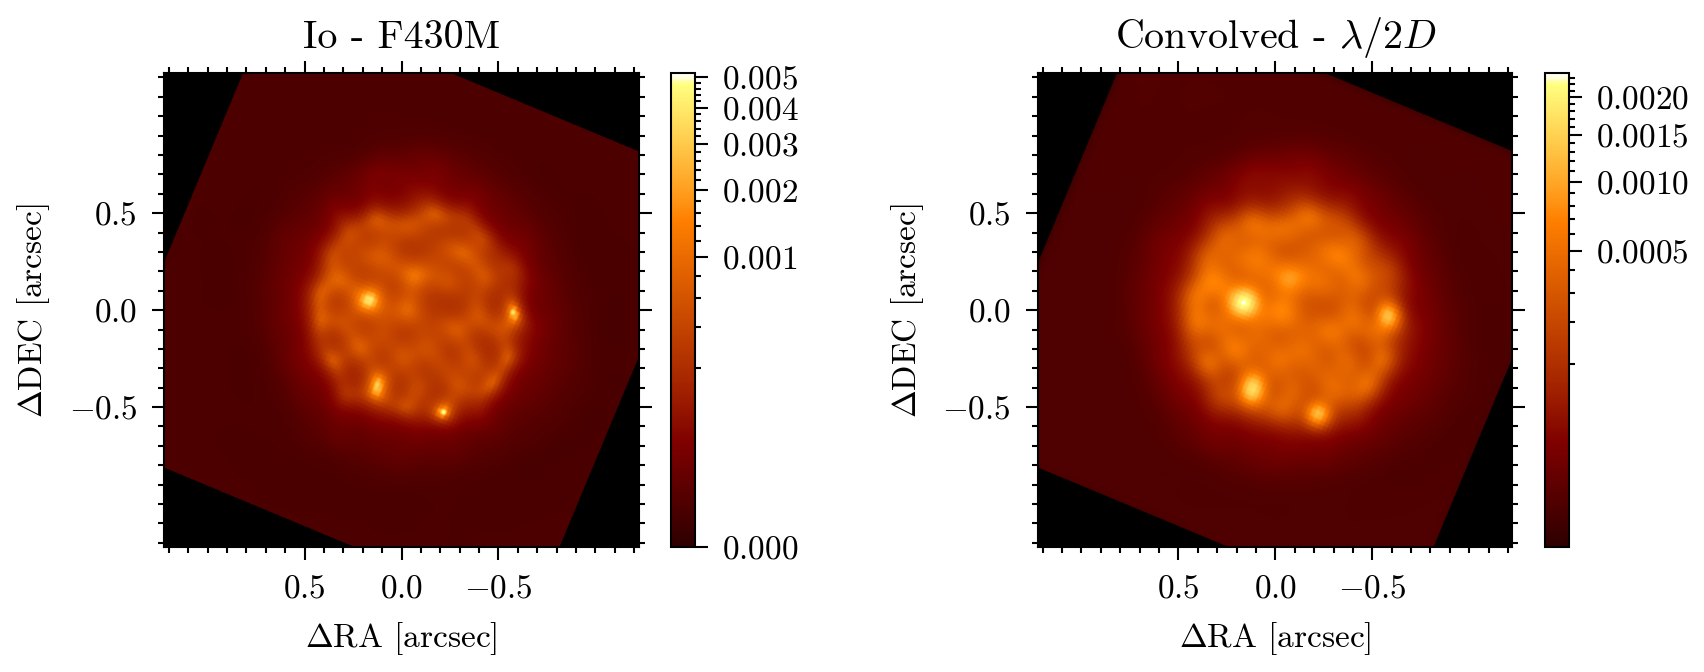

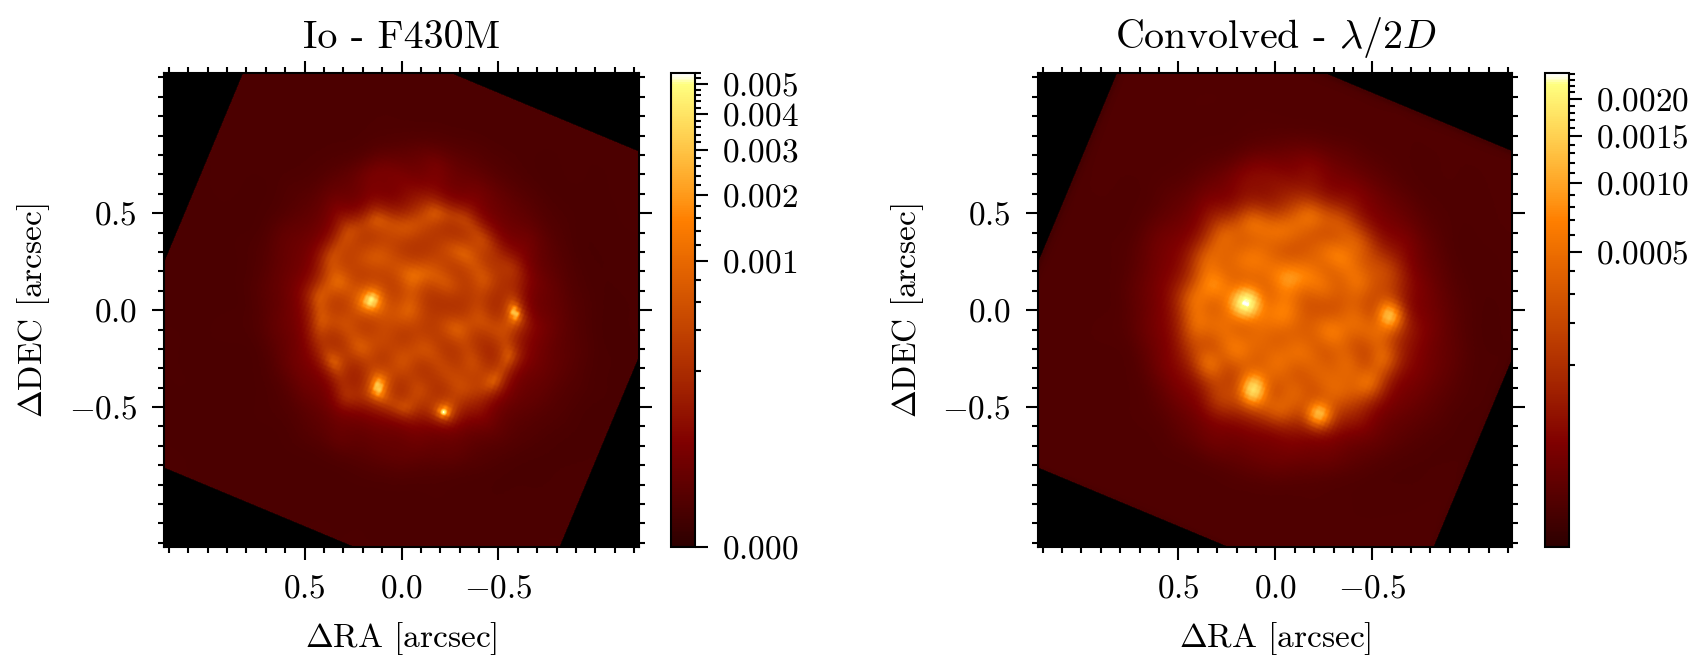

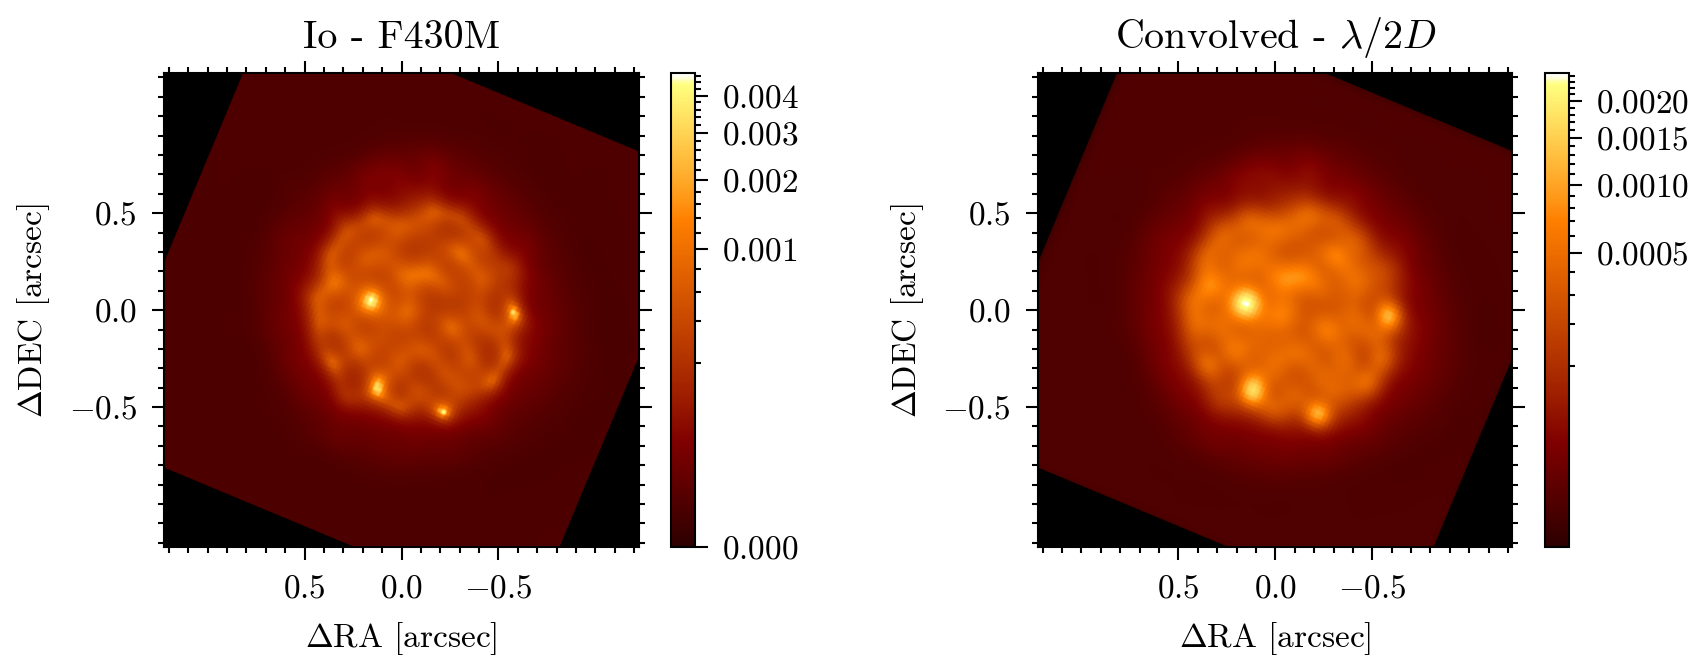

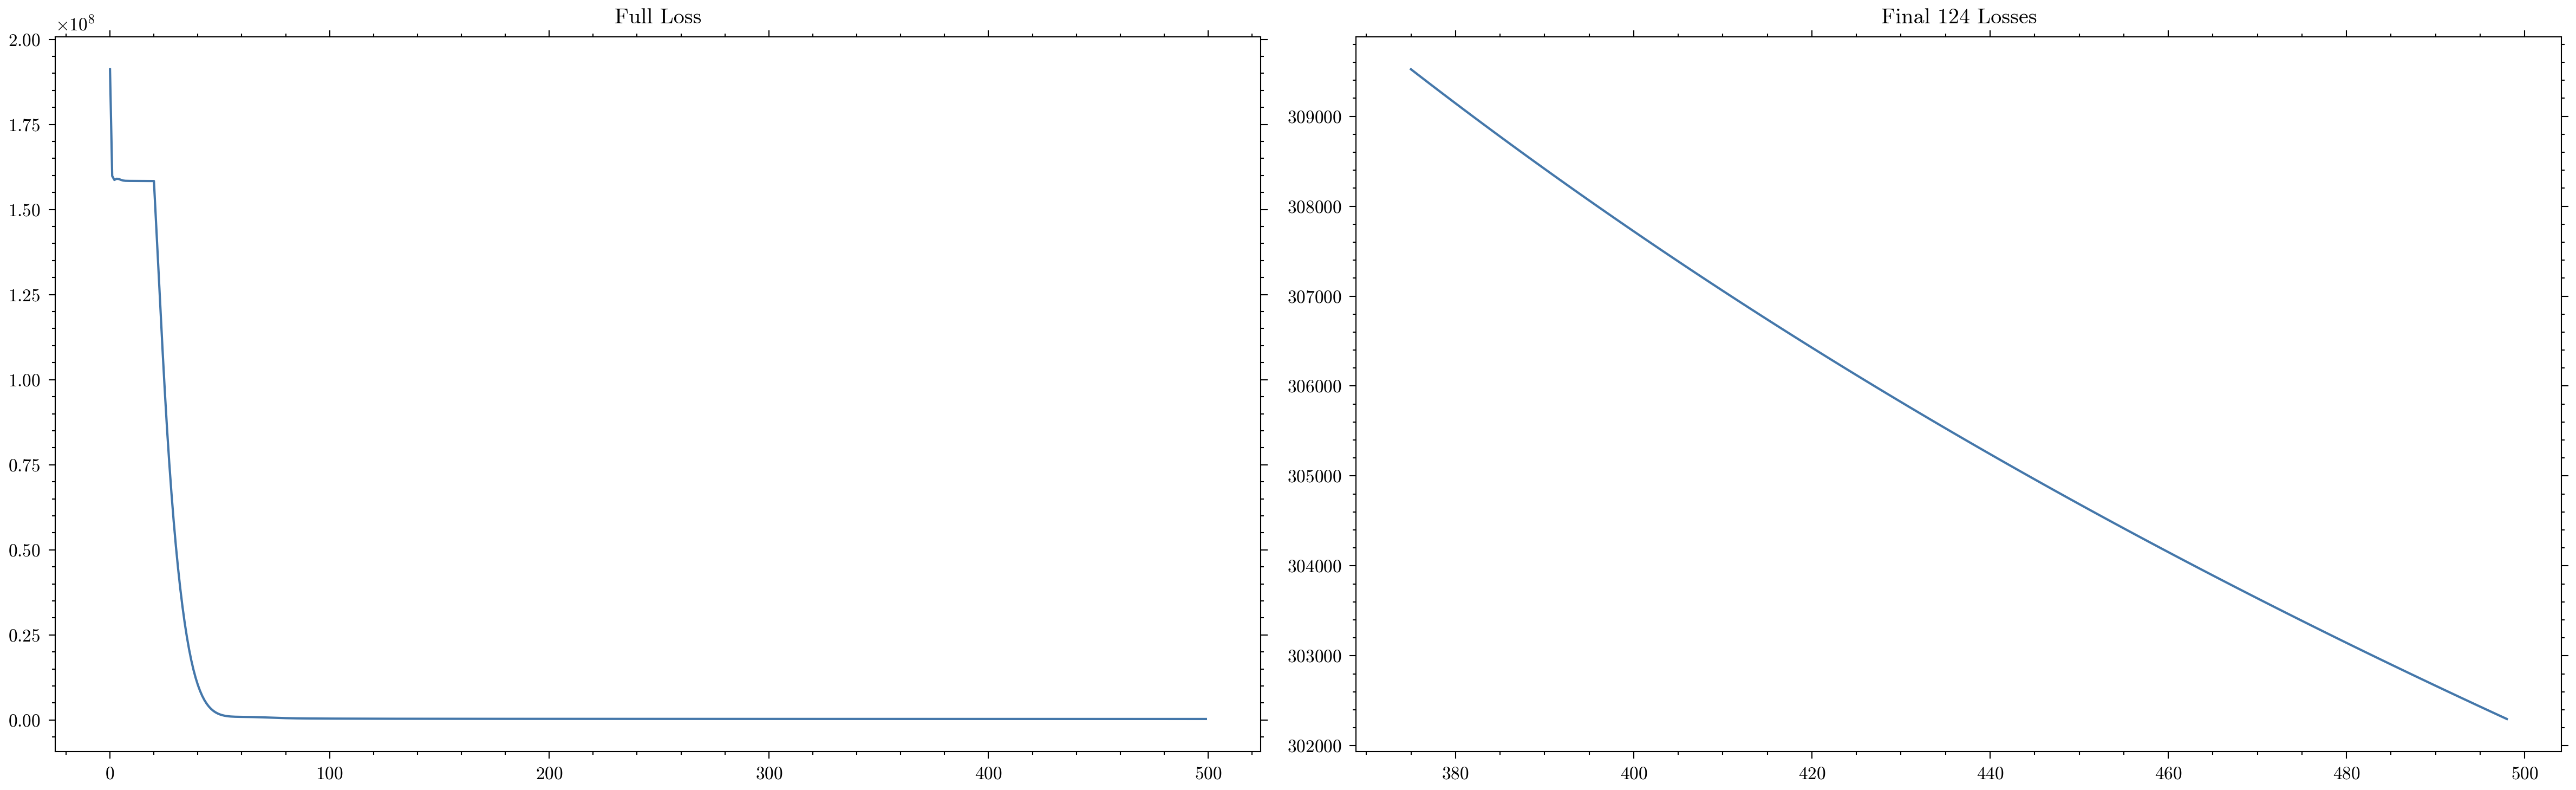

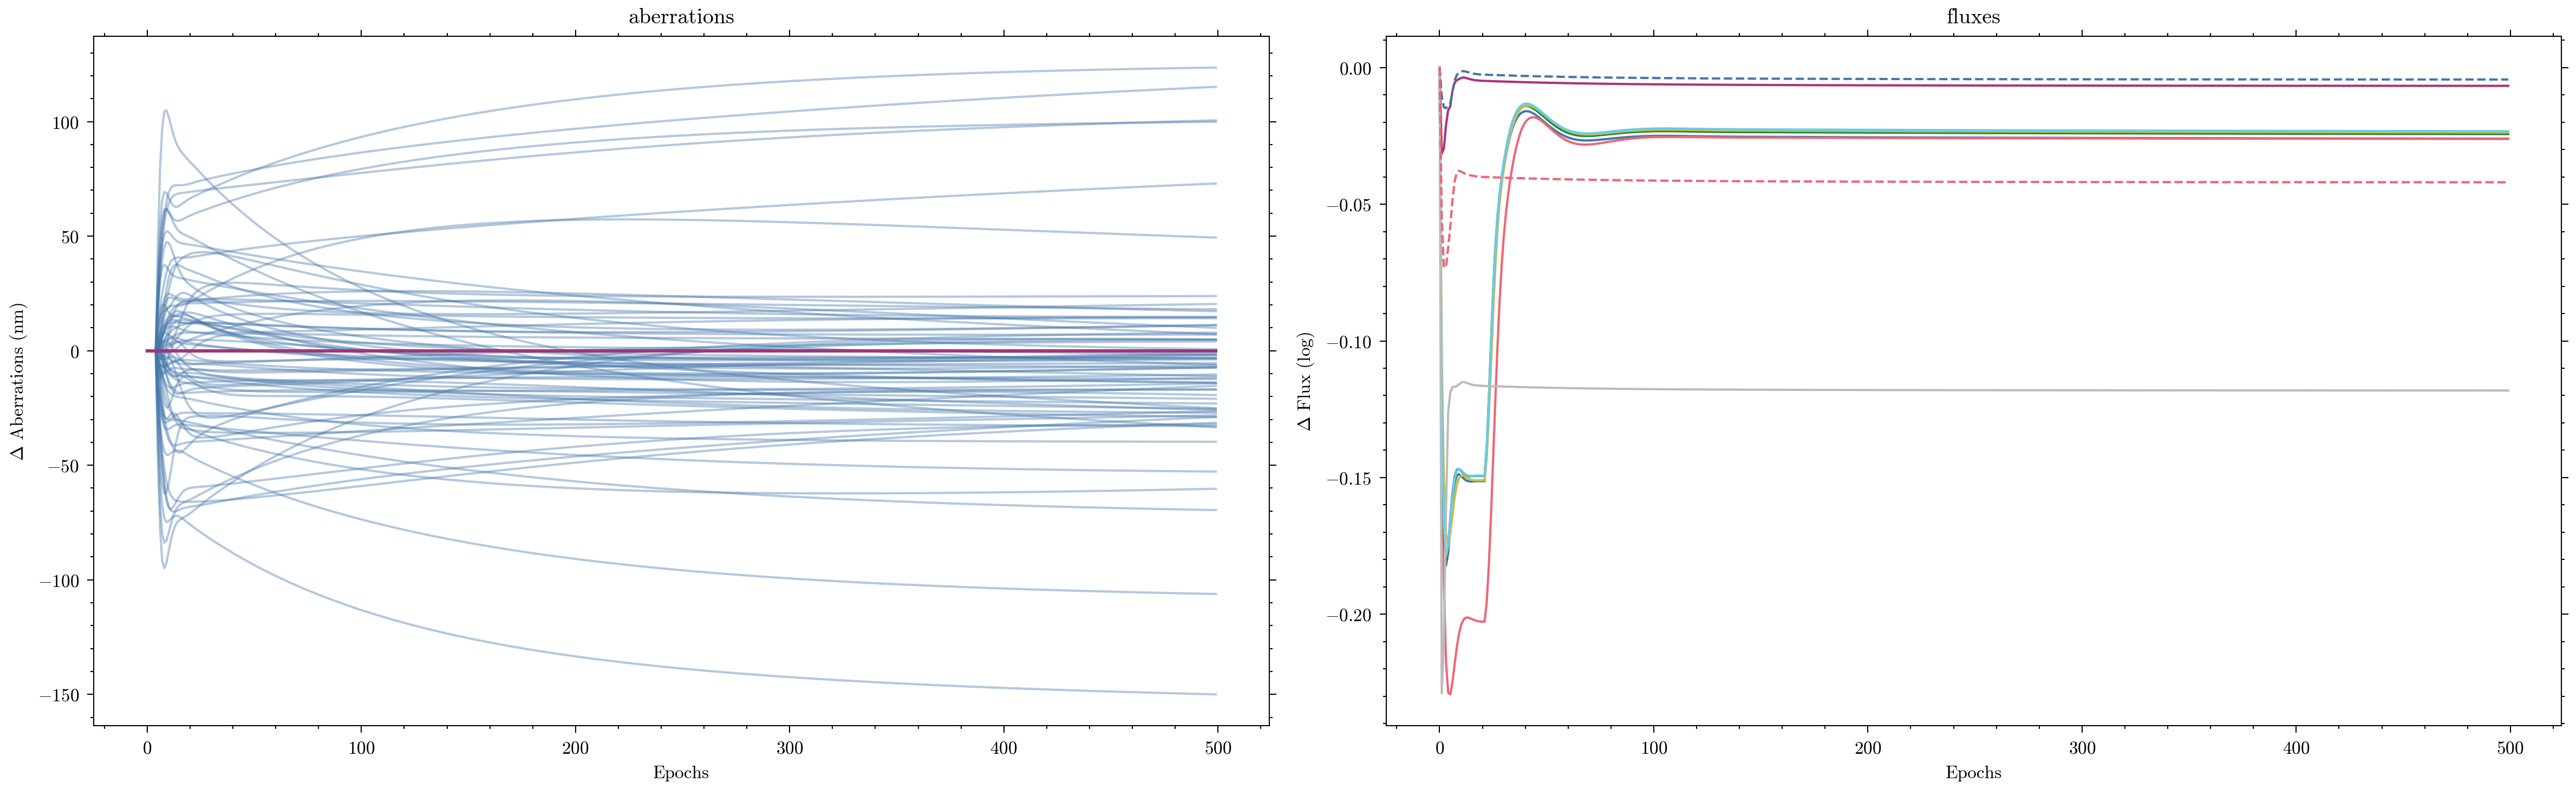

In [ ]:
for res, coeff in zip(results, coeffs):
    print(f"{coeff:.2e}")
    summarise_reconstruction(res.model, fits, result=res)